# Comprehensive EDA

In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Creating Raw Data the required Ticket
raw_data_AAPL = yf.download("AAPL", start="2020-01-01", end="2026-01-01",
                                   auto_adjust=True, progress=False)

df = raw_data_AAPL.copy()

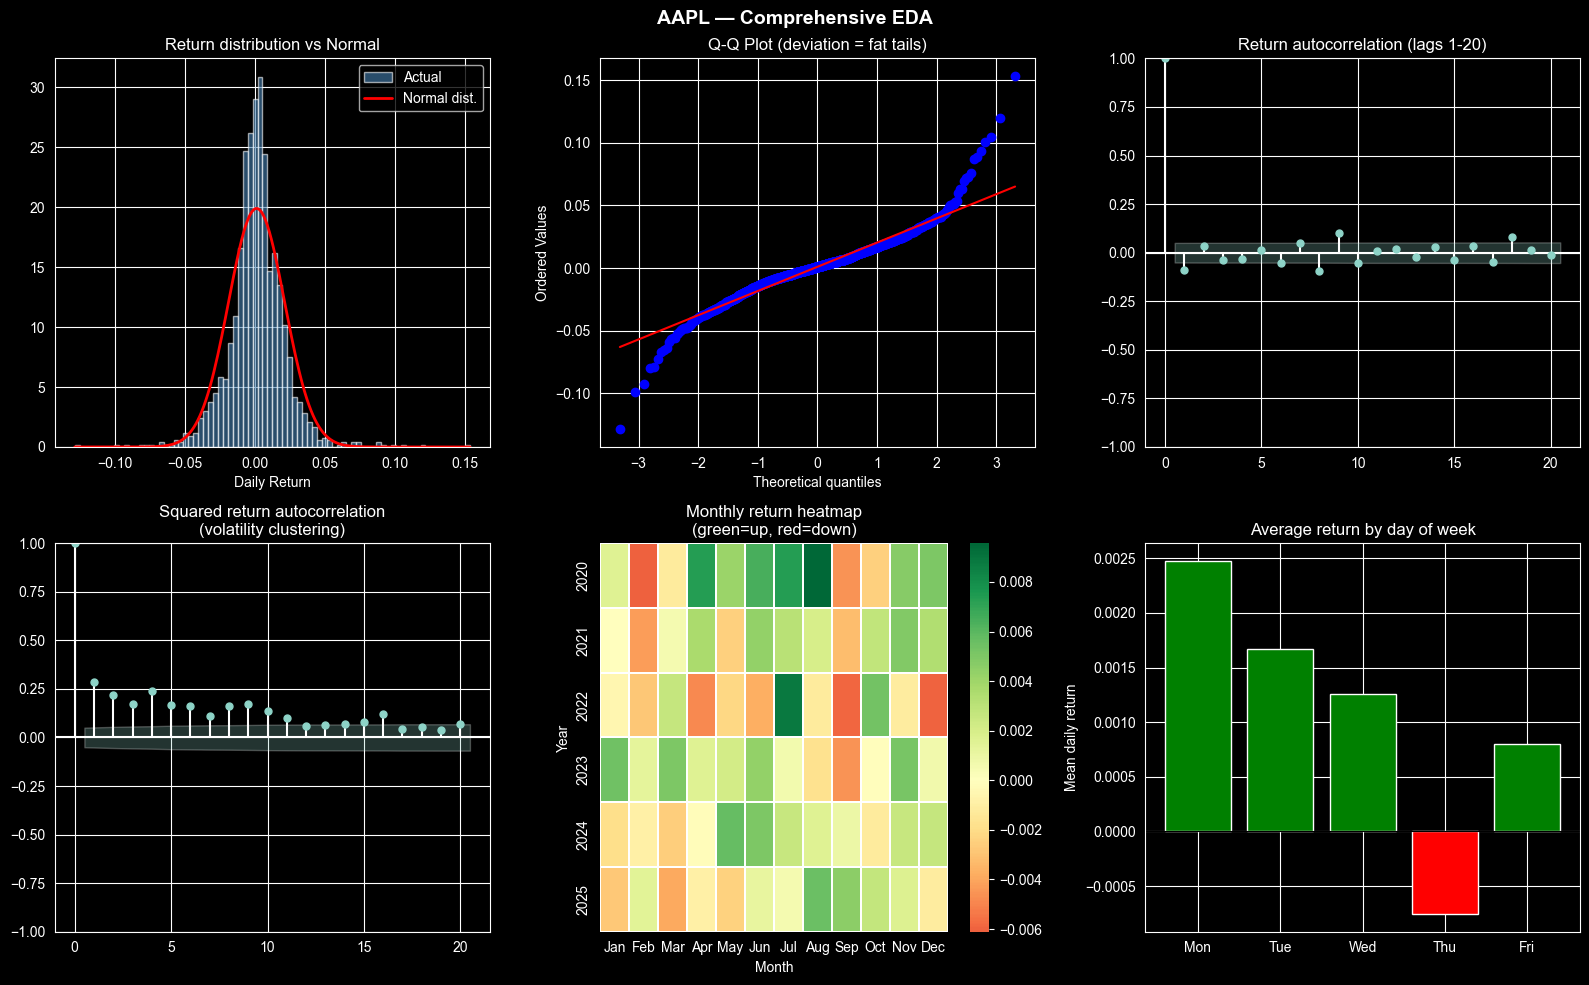

In [42]:
# Rebuild clean df
df = raw_data_AAPL.copy()
df['Daily_return']     = df['Close'].pct_change()
df['Log_return']       = np.log(df['Close'] / df['Close'].shift(1))
df['Next_day_return']  = df['Daily_return'].shift(-1)
df['Target']           = (df['Next_day_return'] > 0).astype(int)

# Distribution of daily returns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('AAPL — Comprehensive EDA', fontsize=14, fontweight='bold')

# Return distribution vs normal curve
returns = df['Daily_return'].dropna()
axes[0,0].hist(returns, bins=80, density=True, alpha=0.6, color='steelblue', label='Actual')
x = np.linspace(returns.min(), returns.max(), 200)
axes[0,0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
               'r-', lw=2, label='Normal dist.')
axes[0,0].set_title('Return distribution vs Normal')
axes[0,0].legend()
axes[0,0].set_xlabel('Daily Return')

# QQ-plot: should be a straight line if returns were normal
stats.probplot(returns, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot (deviation = fat tails)')

# Autocorrelation of returns: is yesterday's return predictive of today's?
# If bars are outside the blue band, there's statistically significant autocorrelation.
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(returns.dropna(), lags=20, ax=axes[0,2], alpha=0.05)
axes[0,2].set_title('Return autocorrelation (lags 1-20)')

# Autocorrelation of SQUARED returns (volatility clustering)
# This is almost always significant — big moves cluster together
plot_acf(returns.dropna()**2, lags=20, ax=axes[1,0], alpha=0.05)
axes[1,0].set_title('Squared return autocorrelation\n(volatility clustering)')

# Monthly return heatmap — seasonality patterns
df['Year']  = df.index.year
df['Month'] = df.index.month
monthly = df.groupby(['Year', 'Month'])['Daily_return'].mean().unstack()
sns.heatmap(monthly, cmap='RdYlGn', center=0, ax=axes[1,1],
            annot=False, linewidths=0.3)
axes[1,1].set_title('Monthly return heatmap\n(green=up, red=down)')
axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])

# Day-of-week effect: do returns differ by weekday?
df['Weekday'] = df.index.dayofweek  # 0=Monday, 4=Friday
dow_returns = df.groupby('Weekday')['Daily_return'].mean()
axes[1,2].bar(['Mon','Tue','Wed','Thu','Fri'], dow_returns.values,
               color=['red' if x < 0 else 'green' for x in dow_returns.values])
axes[1,2].axhline(0, color='black', linewidth=0.8)
axes[1,2].set_title('Average return by day of week')
axes[1,2].set_ylabel('Mean daily return')

plt.tight_layout()
plt.show()

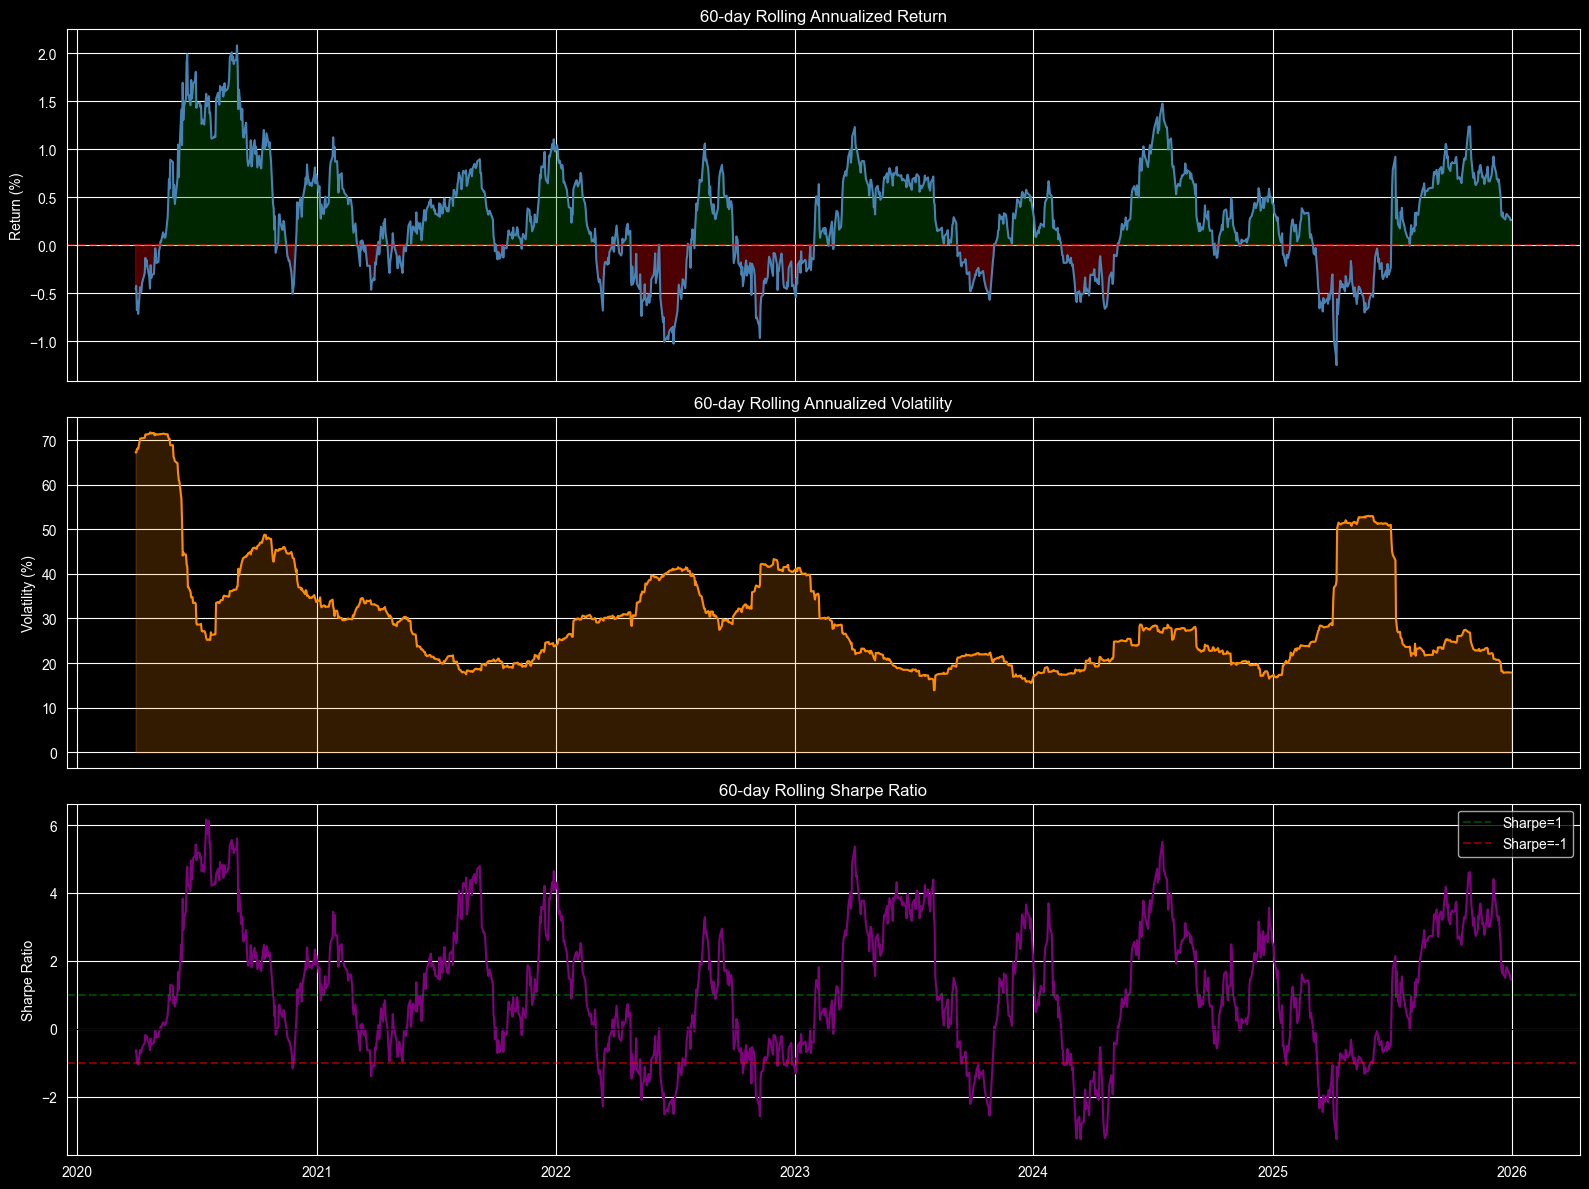

In [43]:
# Rolling statistics: how does the stock's character change over time?
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)


# 1. Ensure the column exists!
df['Daily_return'] = df['Close'].pct_change()

# 2. Now your rolling calculation will work
rolling_mean = df['Daily_return'].rolling(60).mean() * 252  # Annualized

# 60-day rolling mean return
rolling_mean = df['Daily_return'].rolling(60).mean() * 252  # Annualized
axes[0].plot(df.index, rolling_mean, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(df.index, rolling_mean, 0,
                     where=rolling_mean >= 0, alpha=0.3, color='green')
axes[0].fill_between(df.index, rolling_mean, 0,
                     where=rolling_mean < 0, alpha=0.3, color='red')
axes[0].set_title('60-day Rolling Annualized Return')
axes[0].set_ylabel('Return (%)')

# 60-day rolling volatility
rolling_vol = df['Daily_return'].rolling(60).std() * np.sqrt(252) * 100
axes[1].plot(df.index, rolling_vol, color='darkorange')
axes[1].fill_between(df.index, rolling_vol, alpha=0.2, color='darkorange')
axes[1].set_title('60-day Rolling Annualized Volatility')
axes[1].set_ylabel('Volatility (%)')

# 60-day rolling Sharpe-like ratio
rolling_sharpe = (rolling_mean) / (rolling_vol / 100)
axes[2].plot(df.index, rolling_sharpe, color='purple')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(1, color='green', linestyle='--', alpha=0.5, label='Sharpe=1')
axes[2].axhline(-1, color='red', linestyle='--', alpha=0.5, label='Sharpe=-1')
axes[2].set_title('60-day Rolling Sharpe Ratio')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].legend()

plt.tight_layout()
plt.show()

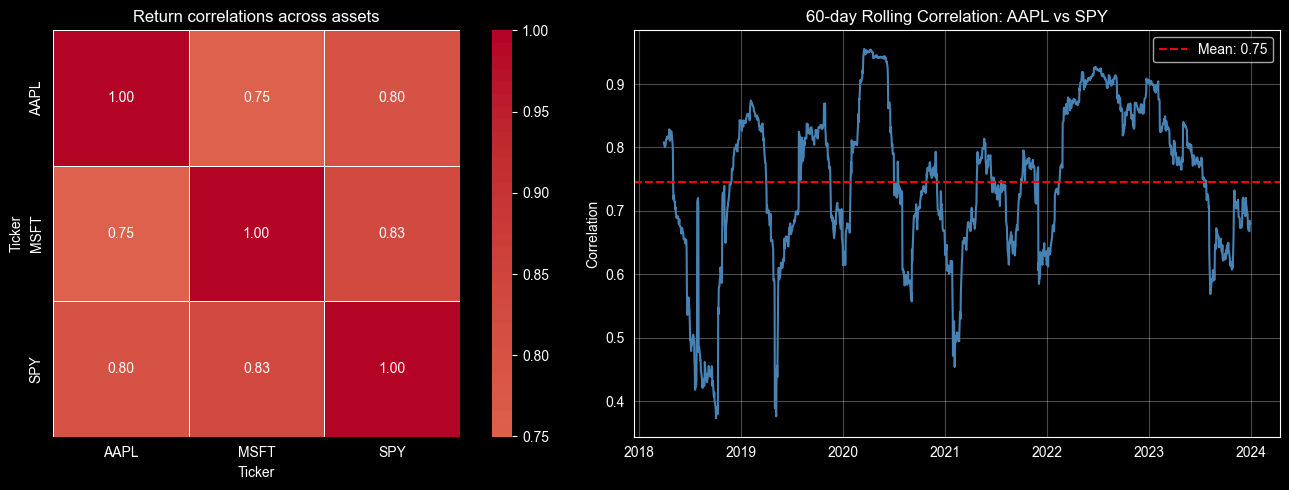


Key EDA findings:
AAPL-SPY correlation: 0.80
AAPL-MSFT correlation: 0.75


In [44]:
# 1. Define the tickers you need for the analysis
tickers = ["AAPL", "SPY", "MSFT"]

# 2. Re-download the data as a group to get the correct structure
# Note: auto_adjust=True is good practice for return calculations
raw_data_all = yf.download(tickers, start="2018-01-01", end="2024-01-01",
                                   auto_adjust=True, progress=False)

# 3. Extract the 'Close' prices for each ticker
# In yfinance MultiIndex, 'Close' is level 0, Ticker is level 1
price_data = raw_data_all['Close'].copy()

# 4. Calculate returns
returns_data = price_data.pct_change().dropna()

# 5. Correlation matrix
corr_matrix = returns_data.corr()

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Return correlations across assets')

# Rolling correlation of AAPL vs SPY (beta changes over time!)
rolling_corr = returns_data['AAPL'].rolling(60).corr(returns_data['SPY'])
axes[1].plot(rolling_corr.index, rolling_corr, color='steelblue')
axes[1].axhline(rolling_corr.mean(), color='red', linestyle='--',
                label=f'Mean: {rolling_corr.mean():.2f}')
axes[1].set_title('60-day Rolling Correlation: AAPL vs SPY')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey EDA findings:")
print(f"AAPL-SPY correlation: {corr_matrix.loc['AAPL','SPY']:.2f}")
print(f"AAPL-MSFT correlation: {corr_matrix.loc['AAPL','MSFT']:.2f}")